# 🌿 Plant Disease Classification (Interactive)

This notebook executes the Hybrid AI approach (ResNet18 + Random Forest) step-by-step.

In [12]:
import os
import time
import cv2
import numpy as np
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Ensure plots display inline
%matplotlib inline

In [13]:
# --- CONFIGURATION ---
# Choose your settings here

# Options: "RESNET18" or "RESNET50"
MODEL_TYPE = "RESNET18" 

# Options: "RF" (Random Forest) or "GB" (Gradient Boosting)
CLASSIFIER_TYPE = "RF"

# Options: None (for all images) or an integer (e.g., 200)
DATA_LIMIT = 200 

# Since we are in a notebook inside 'src', we step back once to get to root
current_dir = Path.cwd()
dataset_path = current_dir.parent / 'dataset'

print(f"📂 Looking for dataset at: {dataset_path}")
print(f"⚙️  Configuration: {MODEL_TYPE} + {CLASSIFIER_TYPE} (Limit: {DATA_LIMIT})")

📂 Looking for dataset at: d:\University\Final Year CSE\Semester1\Elective 3 Image Processing\Project\PlantVillage\dataset
⚙️  Configuration: RESNET18 + RF (Limit: 200)


In [14]:
# --- SETUP AI FEATURE EXTRACTOR ---
# Check for GPU availability
print("🔍 Checking for GPU availability...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Using Device: {device}") 
if device.type == 'cuda':
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")

print(f"🧠 Loading {MODEL_TYPE}...")
if MODEL_TYPE == 'RESNET50':
    weights = models.ResNet50_Weights.DEFAULT
    resnet = models.resnet50(weights=weights)
else:
    weights = models.ResNet18_Weights.DEFAULT
    resnet = models.resnet18(weights=weights)

resnet = torch.nn.Sequential(*(list(resnet.children())[:-1])) # Remove last layer

# MOVE MODEL TO GPU
resnet = resnet.to(device) 
resnet.eval()

# Image Preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def get_vector(img_path):
    input_image = Image.open(img_path).convert('RGB')
    input_tensor = preprocess(input_image)
    
    # MOVE INPUT TO GPU
    input_batch = input_tensor.unsqueeze(0).to(device) 
    
    with torch.no_grad():
        output = resnet(input_batch)
    
    # MOVE OUTPUT BACK TO CPU FOR NUMPY
    return output.cpu().squeeze().numpy()

def load_data_with_ai(base_path, limit=200):
    features_list = []
    labels_list = []
    class_names = os.listdir(base_path)
    
    print(f"⏳ Processing images with {MODEL_TYPE} features...")
    
    for class_name in class_names:
        if class_name == "PlantVillage": continue
        
        class_dir = os.path.join(base_path, class_name)
        if not os.path.isdir(class_dir): continue
        
        all_files = os.listdir(class_dir)
        # Apply limit if provided (None means all files)
        file_list = all_files[:limit] if limit else all_files
        
        print(f"   Extracting features for: {class_name} ({len(file_list)} images)")
        
        for img_name in file_list:
            img_path = os.path.join(class_dir, img_name)
            try:
                vector = get_vector(img_path)
                features_list.append(vector)
                labels_list.append(class_name)
            except Exception as e:
                print(f"Error reading {img_name}: {e}")
                
    return np.array(features_list), np.array(labels_list)

🔍 Checking for GPU availability...
🚀 Using Device: cuda
   GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
🧠 Loading RESNET18...


In [15]:
# Execute Data Loading
start_time = time.time()
X, y = load_data_with_ai(dataset_path, limit=DATA_LIMIT)
duration = time.time() - start_time

if len(X) == 0:
    print("❌ No data loaded. Check your dataset path.")
else:
    print(f"\n✅ Data Processed. Shape: {X.shape}")
    print(f"⏱️  Feature Extraction took: {duration:.2f}s")

⏳ Processing images with RESNET18 features...
   Extracting features for: Pepper__bell___Bacterial_spot (200 images)
   Extracting features for: Pepper__bell___healthy (200 images)
   Extracting features for: Pepper__bell___healthy (200 images)
   Extracting features for: Potato___Early_blight (200 images)
   Extracting features for: Potato___Early_blight (200 images)
   Extracting features for: Potato___healthy (152 images)
   Extracting features for: Potato___healthy (152 images)
   Extracting features for: Potato___Late_blight (200 images)
   Extracting features for: Potato___Late_blight (200 images)
   Extracting features for: Tomato_Bacterial_spot (200 images)
   Extracting features for: Tomato_Bacterial_spot (200 images)
   Extracting features for: Tomato_Early_blight (200 images)
   Extracting features for: Tomato_Early_blight (200 images)
   Extracting features for: Tomato_healthy (200 images)
   Extracting features for: Tomato_healthy (200 images)
   Extracting features for: T

In [16]:
# Split Data
if len(X) > 0:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train Classifier
    print(f"🚀 Training {CLASSIFIER_TYPE} Model...")
    start_time = time.time()

    if CLASSIFIER_TYPE == 'GB':
        model = HistGradientBoostingClassifier(
            max_iter=1000,
            learning_rate=0.1,
            class_weight='balanced',
            random_state=42
        )
    else:
        # Random Forest
        model = RandomForestClassifier(
            n_estimators=500, 
            class_weight='balanced', 
            random_state=42, 
            n_jobs=-1
        )

    model.fit(X_train, y_train)
    train_duration = time.time() - start_time
    print(f"⏱️  Training took: {train_duration:.2f}s")

    # Predictions
    print("📊 Evaluating...")
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"✨ Accuracy: {acc * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

🚀 Training RF Model...
⏱️  Training took: 1.77s
📊 Evaluating...
✨ Accuracy: 83.08%

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.93      0.87      0.90        45
                     Pepper__bell___healthy       0.87      0.97      0.92        40
                      Potato___Early_blight       0.91      0.96      0.94        54
                       Potato___Late_blight       0.92      0.79      0.85        43
                           Potato___healthy       0.82      0.90      0.86        20
                      Tomato_Bacterial_spot       0.65      0.81      0.72        37
                        Tomato_Early_blight       0.59      0.49      0.53        41
                         Tomato_Late_blight       0.85      0.66      0.74        35
                           Tomato_Leaf_Mold       0.81      0.89      0.85        38
                  Tomato_Septoria_leaf_spo

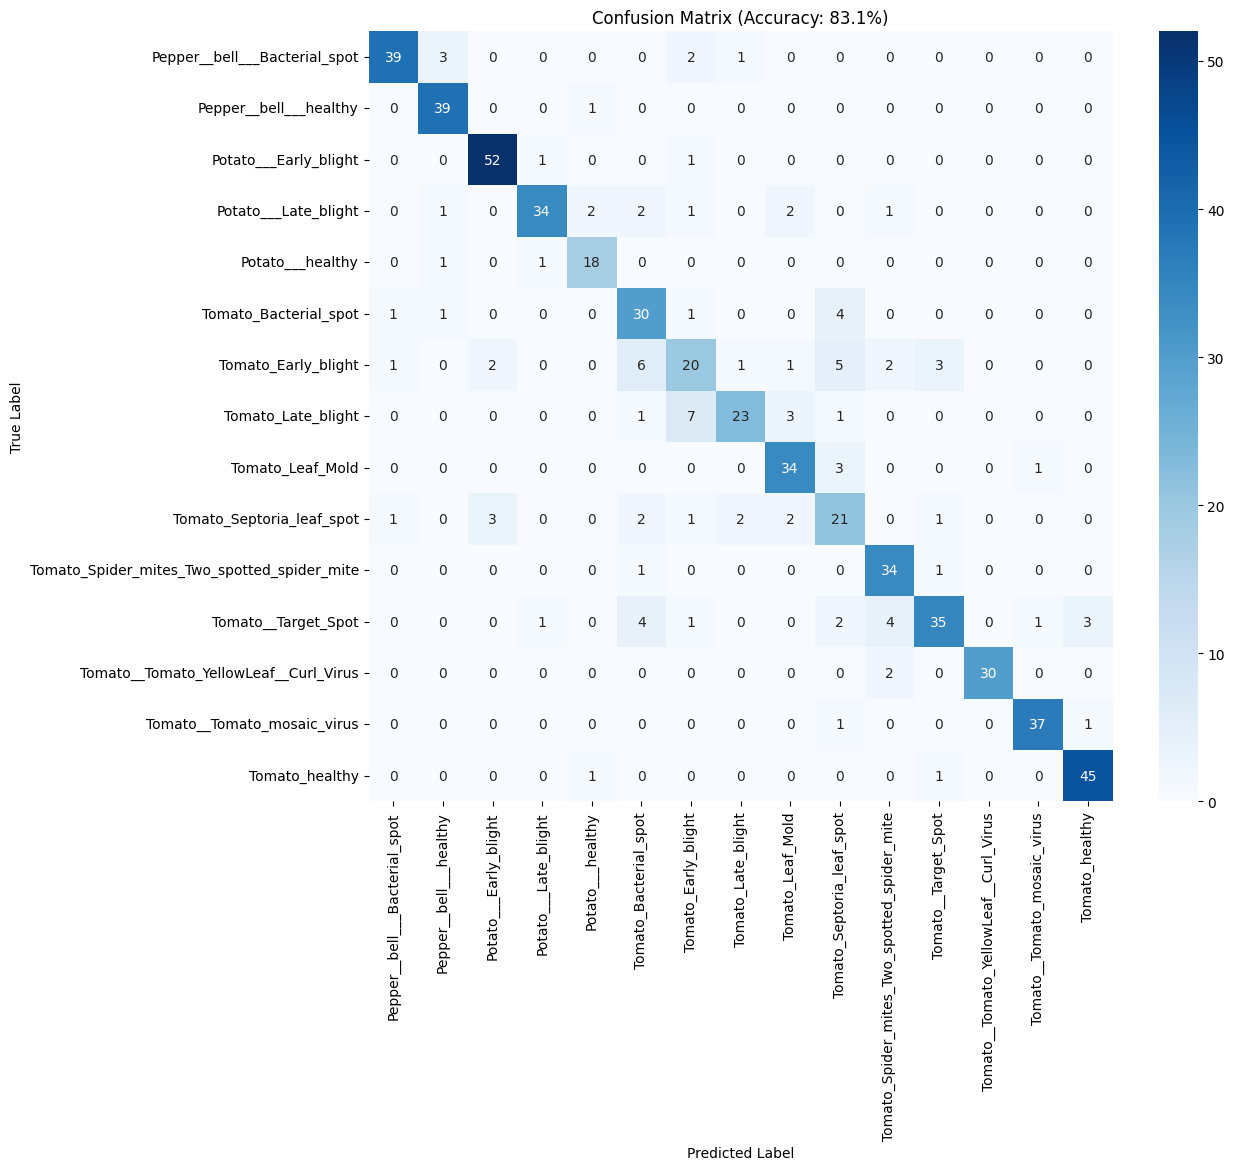

In [17]:
# Confusion Matrix
if len(X) > 0:
    unique_classes = sorted(list(set(y)))
    cm = confusion_matrix(y_test, y_pred, labels=unique_classes)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=unique_classes, yticklabels=unique_classes)
    plt.title(f'Confusion Matrix (Accuracy: {acc*100:.1f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=90)
    plt.show()